# Task 1: Titanic Passenger Survival Prediction System

**Name:** Muhammad Hassan Yousaf  
**Roll Number:** FA24-BSE-082  
**Course:** Machine Learning (CSC-461)  

### Live Cloud Deployment
- **Streamlit App:** https://titanic-model-hassan.streamlit.app
- **Modal App:** https://mhassan0000--titanic-predictor-run.modal.run
- **GitHub Repository:** https://github.com/MHassan0000/ML-Prediction-Models

---
### Overview
In this task, we build an end to end machine learning pipeline to predict passenger survival on the Titanic using a Support Vector Classifier (SVC). The implementation follows the standard ML lifecycle steps:
1. Data Collection
2. Data Understanding and EDA
3. Data Preprocessing and Label Encoding
4. Model Training (SVC with RBF kernel)
5. Model Evaluation
6. Predictions on Sample Data
7. Saving the Trained Model



## 0. Import Libraries
We import pandas, numpy, seaborn, matplotlib, and scikit-learn modules.


In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Data Collection
Load the Titanic dataset from local data folder or seaborn.


In [2]:
# Load dataset
data_path = "data/titanic.csv" if os.path.exists("data/titanic.csv") else "titanic.csv"

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Loaded dataset from {data_path}")
else:
    df = sns.load_dataset("titanic")
    print("Loaded dataset from seaborn")

print("Dataset shape:", df.shape)
df.head()


Loaded dataset from data/titanic.csv
Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Data Understanding and Exploratory Data Analysis
Review data structure, column types, statistics, missing values, and visual distributions.


In [3]:
# Column info and summary statistics
print("Column Information:")
df.info()

print("\nDescriptive Statistics:")
df.describe()


Column Information:


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 116.9 KB

Descriptive Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nSurvival distribution:")
print(df['survived'].value_counts())


Missing values per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Survival distribution:
survived
0    549
1    342
Name: count, dtype: int64


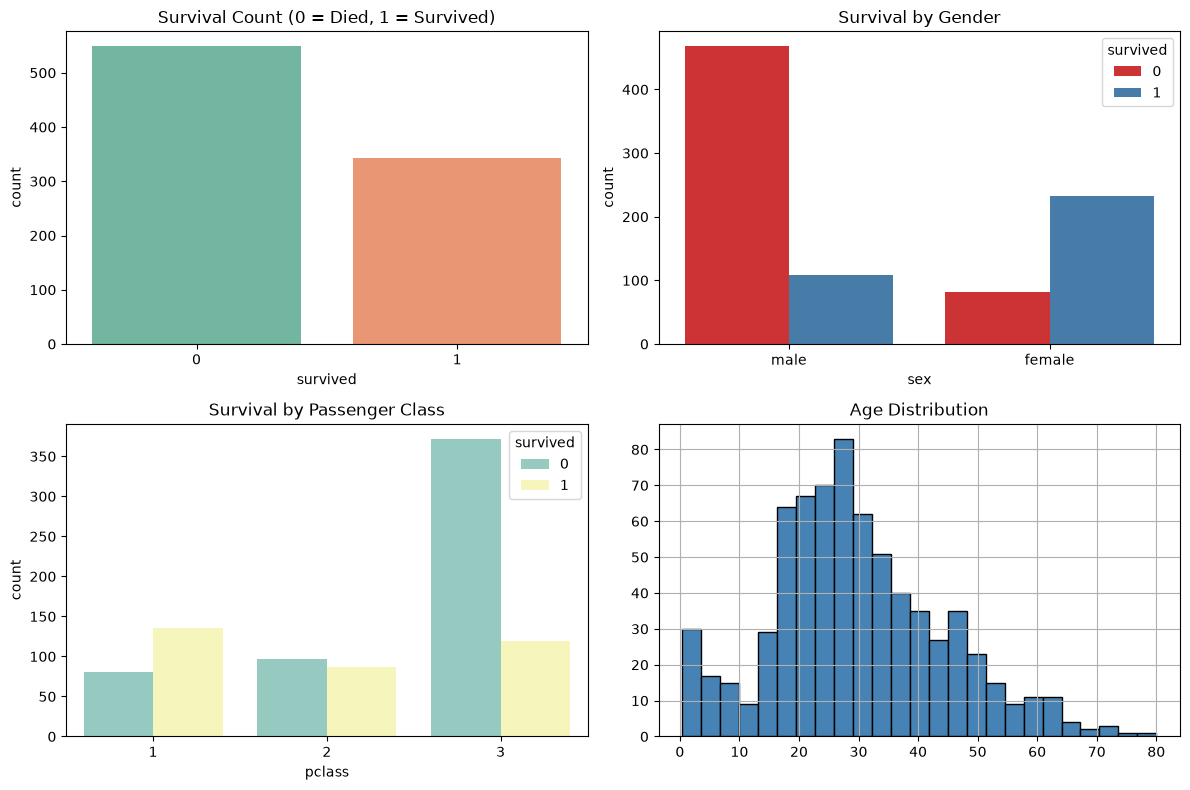

In [5]:
# EDA plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Overall survival count
sns.countplot(data=df, x='survived', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Survival Count (0 = Died, 1 = Survived)')

# 2. Survival by sex
sns.countplot(data=df, x='sex', hue='survived', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Survival by Gender')

# 3. Survival by passenger class
sns.countplot(data=df, x='pclass', hue='survived', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Survival by Passenger Class')

# 4. Age distribution
df['age'].dropna().hist(bins=25, ax=axes[1, 1], color='steelblue', edgecolor='black')
axes[1, 1].set_title('Age Distribution')

plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/titanic_eda.png", dpi=100)
plt.show()


## 3. Data Preprocessing and Label Encoding
Select the 7 required features: pclass, sex, age, sibsp, parch, fare, and embarked. Handle missing values and encode categorical attributes.


In [6]:
# Feature selection
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

df_clean = df[features + [target]].dropna().copy()
print("Shape after dropping nulls:", df_clean.shape)

# Encode sex and embarked columns
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df_clean['sex'] = le_sex.fit_transform(df_clean['sex'])
df_clean['embarked'] = le_embarked.fit_transform(df_clean['embarked'])

# Save encoded dataset
os.makedirs("data", exist_ok=True)
df_clean.to_csv("data/titanic_encoded.csv", index=False)
df_clean.head()


Shape after dropping nulls: (712, 8)


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,1,22.0,1,0,7.2500,2,0
1,1,0,38.0,1,0,71.2833,0,1
2,3,0,26.0,0,0,7.9250,2,1
3,1,0,35.0,1,0,53.1000,2,1
4,3,1,35.0,0,0,8.0500,2,0


## 4. Model Training (Support Vector Classifier)
Split data into 80% training and 20% testing sets, then fit an SVC model with RBF kernel.


In [7]:
# Train-test split
X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Train SVC
svc_model = SVC(kernel='rbf', random_state=42)
svc_model.fit(X_train, y_train)
print("SVC model trained successfully.")


Training samples: 569
Testing samples: 143
SVC model trained successfully.


## 5. Model Evaluation
Calculate accuracy, generate confusion matrix, and print classification report.


Test Accuracy: 63.64%

Confusion Matrix:
[[67 13]
 [39 24]]

Classification Report:
              precision    recall  f1-score   support

        Died       0.63      0.84      0.72        80
    Survived       0.65      0.38      0.48        63

    accuracy                           0.64       143
   macro avg       0.64      0.61      0.60       143
weighted avg       0.64      0.64      0.61       143



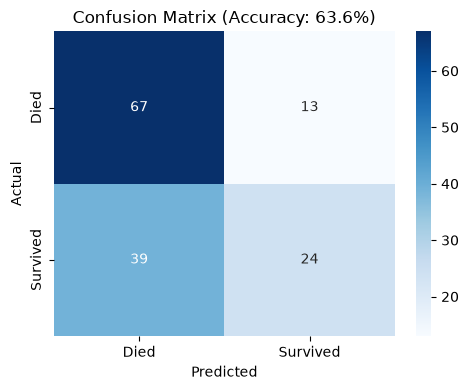

In [8]:
# Evaluate model
y_pred = svc_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy: {acc * 100:.2f}%\n")
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title(f"Confusion Matrix (Accuracy: {acc*100:.1f}%)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("reports/titanic_confusion_matrix.png", dpi=100)
plt.show()


## 6. Testing Predictions
Test model predictions on sample passenger profiles.


In [9]:
# Sample predictions
sample_data = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 29.0, "sibsp": 0, "parch": 0, "fare": 211.0, "embarked": "S"},
    {"pclass": 3, "sex": "male",   "age": 22.0, "sibsp": 1, "parch": 0, "fare": 7.25,  "embarked": "S"},
    {"pclass": 2, "sex": "female", "age": 35.0, "sibsp": 1, "parch": 0, "fare": 26.0,  "embarked": "C"}
])

sample_encoded = sample_data.copy()
sample_encoded['sex'] = le_sex.transform(sample_encoded['sex'])
sample_encoded['embarked'] = le_embarked.transform(sample_encoded['embarked'])

predictions = svc_model.predict(sample_encoded[features])
sample_data['Predicted_Survival'] = ['Survived' if p == 1 else 'Did Not Survive' for p in predictions]

os.makedirs("reports", exist_ok=True)
sample_data.to_csv("reports/titanic_predictions.csv", index=False)
sample_data


,pclass,sex,age,sibsp,parch,fare,embarked,Predicted_Survival
0,1,female,29.0,0,0,211.00,S,Survived
1,3,male,22.0,1,0,7.25,S,Did Not Survive
2,2,female,35.0,1,0,26.00,C,Did Not Survive


## 7. Saving the Trained Model
Serialize the model using pickle for deployment.


In [10]:
# Save model
os.makedirs("models", exist_ok=True)
with open("models/titanic_svc_model.pkl", "wb") as f:
    pickle.dump(svc_model, f)

print("Model saved to models/titanic_svc_model.pkl")


Model saved to models/titanic_svc_model.pkl
